In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import torch

from moc_repro import prepare_contiguous_lm_data
from moc_repro.hf_llama import HFLlamaConfig, benchmark_hf_llama_pair, train_hf_llama_pair

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
dataset = prepare_contiguous_lm_data(
    source_name='wikitext2_raw',
    tokenizer_name='hf-internal-testing/llama-tokenizer',
    cache_dir='data',
)

projection_mode = 'sparse_downproj'
row_chunk_size = 8

model_cfg = HFLlamaConfig(
    vocab_size=dataset.vocab_size,
    hidden_size=512,
    intermediate_size=1024,
    num_hidden_layers=8,
    num_attention_heads=8,
    max_position_embeddings=2048,
    attention_dropout=0.0,
)

dataset

TextDataset(name='wikitext2_raw', tokenizer_name='hf-internal-testing/llama-tokenizer', text_path=PosixPath('data/wikitext2_raw.txt'), train_tokens=array([    1, 29871,    13, ...,   450,  9338, 29909]), val_tokens=array([ 5492,   278,  6666, ...,    13, 29871,    13]), vocab_size=32001)

In [4]:
pair_runs = train_hf_llama_pair(
    dataset=dataset,
    model_cfg=model_cfg,
    block_size=512,
    batch_size=4,
    steps=60,
    learning_rate=3e-4,
    eval_interval=15,
    eval_batches=4,
    seed=42,
    sparsity_ratio=0.75,
    device=device,
    projection_mode=projection_mode,
    row_chunk_size=row_chunk_size,
)

pair_runs

/usr/local/lib/python3.10/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/usr/local/lib/python3.10/dist-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


{'dense': {'history': [{'step': 1,
    'train_loss': 10.436922073364258,
    'val_loss': 10.109154224395752},
   {'step': 15, 'train_loss': 8.072532653808594, 'val_loss': 7.96177065372467},
   {'step': 30,
    'train_loss': 7.105093955993652,
    'val_loss': 7.113211750984192},
   {'step': 45, 'train_loss': 6.804924488067627, 'val_loss': 7.09473443031311},
   {'step': 60,
    'train_loss': 6.907909870147705,
    'val_loss': 7.164915680885315}],
  'summary': {'batch_size': 4,
   'block_size': 512,
   'steps': 60,
   'learning_rate': 0.0003,
   'eval_interval': 15,
   'eval_batches': 4,
   'seed': 42,
   'elapsed_sec': 12.71267557144165,
   'tokens_per_sec': 9665.94320050481,
   'peak_memory_mb': 1970.30078125,
   'final_train_loss': 6.907909870147705,
   'final_val_loss': 7.164915680885315,
   'final_train_ppl': 1000.1546020507812,
   'final_val_ppl': 1293.25244140625}},
 'moc': {'history': [{'step': 1,
    'train_loss': 10.444321632385254,
    'val_loss': 10.103734731674194},
   {'step

In [2]:
from moc_repro import prepare_contiguous_lm_data, profile_hf_pair
from moc_repro.hf_llama import HFLlamaConfig

dataset = prepare_contiguous_lm_data(
    source_name='wikitext2_raw',
    tokenizer_name='hf-internal-testing/llama-tokenizer',
    cache_dir='data',
)

model_cfg = HFLlamaConfig(
    vocab_size=dataset.vocab_size,
    hidden_size=512,
    intermediate_size=1024,
    num_hidden_layers=8,
    num_attention_heads=8,
    max_position_embeddings=2048,
    attention_dropout=0.0,
)

profile_rows = profile_hf_pair(
    dataset=dataset,
    model_cfg=model_cfg,
    projection_mode='sparse_downproj',
    sparsity_ratio=0.75,
    row_chunk_size=8,
    block_size=512,
    batch_size=4,
    warmup_steps=2,
    active_steps=3,
    learning_rate=3e-4,
    seed=42,
    device='cuda',
    output_dir='profiling_artifacts/hf_llama',
)
profile_rows


/usr/local/lib/python3.10/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/usr/local/lib/python3.10/dist-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


[{'model': 'dense',
  'trace_path': 'profiling_artifacts/hf_llama/dense_trace.json',
  'summary_path': 'profiling_artifacts/hf_llama/dense_summary.txt',
  'selected_events_json': 'profiling_artifacts/hf_llama/dense_selected_events.json',
  'sort_by': 'self_cuda_time_total'},
 {'model': 'moc',
  'trace_path': 'profiling_artifacts/hf_llama/moc_trace.json',
  'summary_path': 'profiling_artifacts/hf_llama/moc_summary.txt',
  'selected_events_json': 'profiling_artifacts/hf_llama/moc_selected_events.json',
  'sort_by': 'self_cuda_time_total'}]

In [5]:
history_rows = []
for model_name, payload in pair_runs.items():
    for point in payload['history']:
        history_rows.append({'model': model_name, **point})
    history_rows.append({'model': model_name, 'step': 'summary', **payload['summary']})

history_df = pd.DataFrame(history_rows)
summary_df = history_df[history_df['step'] == 'summary'].copy()
summary_df['memory_reduction_pct_vs_dense'] = (
    100.0 * (summary_df.loc[summary_df['model'] == 'dense', 'peak_memory_mb'].iloc[0] - summary_df['peak_memory_mb'])
    / summary_df.loc[summary_df['model'] == 'dense', 'peak_memory_mb'].iloc[0]
)
summary_df['speedup_vs_dense'] = summary_df['tokens_per_sec'] / summary_df.loc[summary_df['model'] == 'dense', 'tokens_per_sec'].iloc[0]
history_df

,model,step,train_loss,val_loss,batch_size,block_size,steps,learning_rate,eval_interval,eval_batches,seed,elapsed_sec,tokens_per_sec,peak_memory_mb,final_train_loss,final_val_loss,final_train_ppl,final_val_ppl
0,dense,1,10.436922,10.109154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,dense,15,8.072533,7.961771,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,dense,30,7.105094,7.113212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,dense,45,6.804924,7.094734,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,dense,60,6.907910,7.164916,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,dense,summary,NaN,NaN,4.0,512.0,60.0,0.0003,15.0,4.0,42.0,12.712676,9665.943201,1970.300781,6.907910,7.164916,1000.154602,1293.252441
6,moc,1,10.444322,10.103735,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,moc,15,8.092777,7.984828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,moc,30,7.115560,7.117153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,moc,45,6.823978,7.098300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


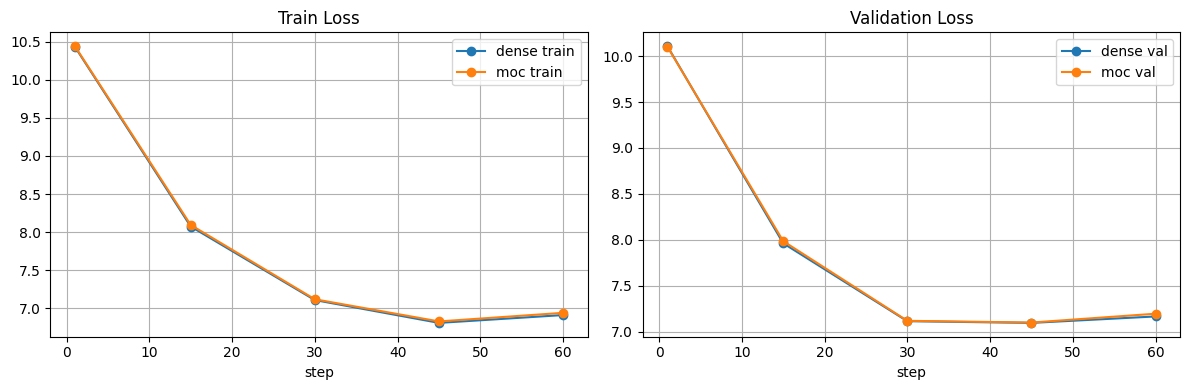

,model,peak_memory_mb,memory_reduction_pct_vs_dense,tokens_per_sec,speedup_vs_dense,final_train_loss,final_val_loss,final_train_ppl,final_val_ppl
5,dense,1970.300781,0.000000,9665.943201,1.000000,6.907910,7.164916,1000.154602,1293.252441
11,moc,1794.300781,8.932646,2209.988542,0.228637,6.937137,7.194645,1029.817749,1332.276611


In [6]:
curve_df = history_df[history_df['step'] != 'summary'].copy()
curve_df['step'] = curve_df['step'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for model_name in ['dense', 'moc']:
    part = curve_df[curve_df['model'] == model_name]
    axes[0].plot(part['step'], part['train_loss'], marker='o', label=f'{model_name} train')
    axes[1].plot(part['step'], part['val_loss'], marker='o', label=f'{model_name} val')

axes[0].set_title('Train Loss')
axes[1].set_title('Validation Loss')
for ax in axes:
    ax.set_xlabel('step')
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

summary_df[['model', 'peak_memory_mb', 'memory_reduction_pct_vs_dense', 'tokens_per_sec', 'speedup_vs_dense', 'final_train_loss', 'final_val_loss', 'final_train_ppl', 'final_val_ppl']]

In [6]:
bench_rows = benchmark_hf_llama_pair(
    dataset=dataset,
    model_cfg=model_cfg,
    block_sizes=(256, 512, 1024, 2048),
    batch_size=4,
    steps=8,
    learning_rate=3e-4,
    seed=42,
    sparsity_ratio=0.75,
    device=device,
    projection_mode=projection_mode,
    row_chunk_size=row_chunk_size,
)

bench_df = pd.DataFrame(bench_rows)
dense_mem = bench_df[bench_df['model'] == 'dense'].set_index('block_size')['peak_memory_mb']
dense_tps = bench_df[bench_df['model'] == 'dense'].set_index('block_size')['tokens_per_sec']
bench_df['memory_reduction_pct_vs_dense'] = bench_df.apply(lambda r: 100.0 * (dense_mem[r['block_size']] - r['peak_memory_mb']) / dense_mem[r['block_size']] if r['status'] == 'ok' else float('nan'), axis=1)
bench_df['speedup_vs_dense'] = bench_df.apply(lambda r: r['tokens_per_sec'] / dense_tps[r['block_size']] if r['status'] == 'ok' else float('nan'), axis=1)
bench_df

,model,block_size,status,tokens_per_sec,peak_memory_mb,final_train_loss,final_train_ppl,memory_reduction_pct_vs_dense,speedup_vs_dense
0,dense,256,ok,10070.103922,1305.812500,8.806905,6680.210449,0.000000,1.000000
1,moc,256,ok,3661.900267,1216.816406,8.834317,6865.864258,6.815381,0.363641
2,dense,512,ok,11941.599838,1970.300781,9.026926,8324.231445,0.000000,1.000000
3,moc,512,ok,3744.455158,1794.300781,9.048892,8509.104492,8.932646,0.313564
4,dense,1024,ok,10976.882359,3310.234375,8.860114,7045.286621,0.000000,1.000000
5,moc,1024,ok,3738.305154,2958.234375,8.878215,7173.972656,10.633688,0.340562
6,dense,2048,ok,10774.333379,5987.113281,8.711922,6074.905273,0.000000,1.000000
7,moc,2048,ok,3660.065170,5284.101562,8.724154,6149.668945,11.742081,0.339702


In [8]:
bench_rows

[{'model': 'dense',
  'block_size': 256,
  'status': 'ok',
  'tokens_per_sec': 10070.103922153636,
  'peak_memory_mb': 1305.8125,
  'final_train_loss': 8.806904792785645,
  'final_train_ppl': 6680.21044921875},
 {'model': 'moc',
  'block_size': 256,
  'status': 'ok',
  'tokens_per_sec': 3661.9002665981743,
  'peak_memory_mb': 1216.81640625,
  'final_train_loss': 8.834317207336426,
  'final_train_ppl': 6865.8642578125},
 {'model': 'dense',
  'block_size': 512,
  'status': 'ok',
  'tokens_per_sec': 11941.599838321463,
  'peak_memory_mb': 1970.30078125,
  'final_train_loss': 9.026926040649414,
  'final_train_ppl': 8324.2314453125},
 {'model': 'moc',
  'block_size': 512,
  'status': 'ok',
  'tokens_per_sec': 3744.4551583368434,
  'peak_memory_mb': 1794.30078125,
  'final_train_loss': 9.0488920211792,
  'final_train_ppl': 8509.1044921875},
 {'model': 'dense',
  'block_size': 1024,
  'status': 'ok',
  'tokens_per_sec': 10976.882358935924,
  'peak_memory_mb': 3310.234375,
  'final_train_loss'

In [7]:
batch_scaling_rows = []
for bsz in [1, 2, 4]:
    rows = benchmark_hf_llama_pair(
        dataset=dataset,
        model_cfg=model_cfg,
        block_sizes=(512,),
        batch_size=bsz,
        steps=8,
        learning_rate=3e-4,
        seed=42,
        sparsity_ratio=0.75,
        device=device,
        projection_mode=projection_mode,
        row_chunk_size=row_chunk_size,
    )
    for row in rows:
        row['batch_size'] = bsz
        batch_scaling_rows.append(row)

batch_scaling_df = pd.DataFrame(batch_scaling_rows)
batch_scaling_df

,model,block_size,status,tokens_per_sec,peak_memory_mb,final_train_loss,final_train_ppl,batch_size
0,dense,512,ok,8031.579206,1041.444824,9.227876,10176.899414,1
1,moc,512,ok,3180.351790,1041.444824,9.242393,10325.723633,1
2,dense,512,ok,10827.325645,1305.937500,8.920149,7481.202637,2
3,moc,512,ok,3598.109697,1216.941406,8.944042,7662.106445,2
4,dense,512,ok,11841.158529,1970.300781,9.026926,8324.231445,4
5,moc,512,ok,3734.329796,1795.296875,9.049671,8515.737305,4


In [9]:
batch_scaling_rows

[{'model': 'dense',
  'block_size': 512,
  'status': 'ok',
  'tokens_per_sec': 8031.579205624953,
  'peak_memory_mb': 1041.44482421875,
  'final_train_loss': 9.227875709533691,
  'final_train_ppl': 10176.8994140625,
  'batch_size': 1},
 {'model': 'moc',
  'block_size': 512,
  'status': 'ok',
  'tokens_per_sec': 3180.351789572402,
  'peak_memory_mb': 1041.44482421875,
  'final_train_loss': 9.242393493652344,
  'final_train_ppl': 10325.7236328125,
  'batch_size': 1},
 {'model': 'dense',
  'block_size': 512,
  'status': 'ok',
  'tokens_per_sec': 10827.325645327388,
  'peak_memory_mb': 1305.9375,
  'final_train_loss': 8.920148849487305,
  'final_train_ppl': 7481.20263671875,
  'batch_size': 2},
 {'model': 'moc',
  'block_size': 512,
  'status': 'ok',
  'tokens_per_sec': 3598.1096971051334,
  'peak_memory_mb': 1216.94140625,
  'final_train_loss': 8.944042205810547,
  'final_train_ppl': 7662.1064453125,
  'batch_size': 2},
 {'model': 'dense',
  'block_size': 512,
  'status': 'ok',
  'tokens_

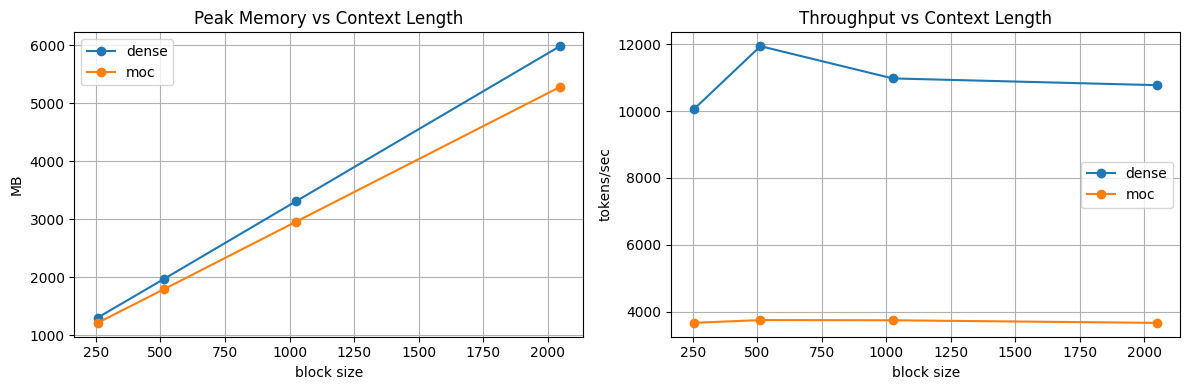

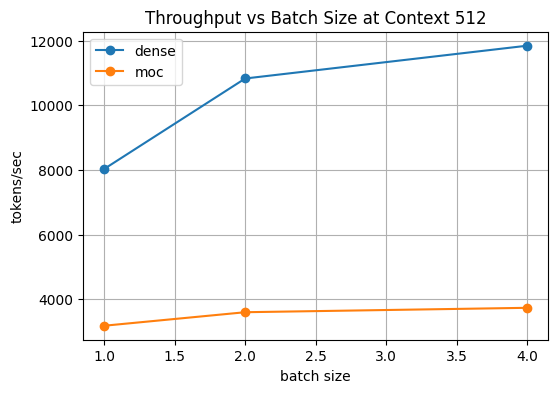

In [10]:
ok_df = bench_df[bench_df['status'] == 'ok']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for model_name in ['dense', 'moc']:
    part = ok_df[ok_df['model'] == model_name]
    axes[0].plot(part['block_size'], part['peak_memory_mb'], marker='o', label=model_name)
    axes[1].plot(part['block_size'], part['tokens_per_sec'], marker='o', label=model_name)

axes[0].set_title('Peak Memory vs Context Length')
axes[1].set_title('Throughput vs Context Length')
axes[0].set_xlabel('block size')
axes[1].set_xlabel('block size')
axes[0].set_ylabel('MB')
axes[1].set_ylabel('tokens/sec')
for ax in axes:
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

batch_ok_df = batch_scaling_df[batch_scaling_df['status'] == 'ok']
plt.figure(figsize=(6, 4))
for model_name in ['dense', 'moc']:
    part = batch_ok_df[batch_ok_df['model'] == model_name]
    plt.plot(part['batch_size'], part['tokens_per_sec'], marker='o', label=model_name)
plt.title('Throughput vs Batch Size at Context 512')
plt.xlabel('batch size')
plt.ylabel('tokens/sec')
plt.grid(True)
plt.legend()
plt.show()